# 실험 3: 타입 엔트로피 주입 (Type Entropy Injection)

동적 환경에서 AISO가 SPSO에 크게 뒤지는 원인: **타입 수렴(Type Convergence)**.
타입 업데이트를 반복하면 $W_i$들이 단일 값으로 수렴 -> $M$이 에이전트를 분산시키지 못함.

**해법**: 타입 업데이트에 Dirichlet 돌연변이 항 추가.

$$W_i \leftarrow (1-\gamma) \cdot \text{normalize}((1-\beta)W_i + \beta W_j) + \gamma \cdot \epsilon, \quad \epsilon \sim \text{Dirichlet}(\mathbf{1})$$

- **고정 gamma**: gamma 스칼라 고정
- **적응형 gamma**: 엔트로피 $H(W)$가 낮아지면 gamma 자동 증가

**목표**: Moving-peaks에서 SPSO 기준선(PR=0.631)을 넘어서기

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(0)

N_AG    = 40
N_TYPES = 6
ALPHA   = 0.2
BETA    = 0.08
M_LOW   = -0.5
W_REPEL = 2.0
N_IT    = 600
T_CHANGE = 20
N_RUNS  = 10

print(f"N_AG={N_AG}, N_TYPES={N_TYPES}, T={N_IT}, runs={N_RUNS}")

N_AG=40, N_TYPES=6, T=600, runs=10


In [2]:
def make_dynamic_gm(n_peaks=6, speed=0.004, sigma=0.07, seed=0):
    rng = np.random.RandomState(seed)
    centers = rng.rand(n_peaks, 2)
    vels    = (rng.rand(n_peaks, 2) - 0.5) * speed * 2
    def get_optima(t):
        c = centers + vels * t
        c = np.where(c < 0, -c, c)
        c = np.where(c > 1, 2 - c, c)
        return np.clip(c, 0.01, 0.99)
    def f_at_t(x, t):
        c = get_optima(t)
        x2 = np.array(x)[:2]
        return -float(sum(np.exp(-np.sum((x2-p)**2)/(2*sigma**2)) for p in c))
    return f_at_t, get_optima, n_peaks

def peak_ratio(X, optima, tol=0.15):
    covered = sum(1 for opt in optima
                  if np.min(np.linalg.norm(X[:, :2] - opt, axis=1)) < tol)
    return covered / len(optima)

def type_entropy(W):
    W_safe = np.clip(W, 1e-10, 1)
    return -np.sum(W_safe * np.log(W_safe), axis=1).mean()

print("환경 함수 정의 완료")

환경 함수 정의 완료


In [3]:
def run_spso_dynamic(seed=0):
    DYN_F, DYN_OPTIMA, _ = make_dynamic_gm(seed=seed)
    rng = np.random.RandomState(seed)
    X = rng.rand(N_AG, 2)
    V = np.zeros((N_AG, 2))
    S = np.array([DYN_F(X[i], 0) for i in range(N_AG)])
    pb = X.copy(); ps = S.copy()
    gb = X[np.argmin(S)].copy(); gs = S.min()
    w_inertia = 0.729; c1 = 1.494; c2 = 1.494
    pr_history = []; current_t = 0
    for it in range(N_IT):
        if it > 0 and it % T_CHANGE == 0:
            current_t = it
            S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
            ps = S.copy(); pb = X.copy()
            gb = X[np.argmin(S)].copy(); gs = S.min()
            pr_history.append(peak_ratio(X, DYN_OPTIMA(current_t)))
        r1 = rng.rand(N_AG, 2); r2 = rng.rand(N_AG, 2)
        V = w_inertia*V + c1*r1*(pb-X) + c2*r2*(gb-X)
        X = np.clip(X + V, 0, 1)
        S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
        better = S < ps
        pb[better] = X[better]; ps[better] = S[better]
        if S.min() < gs:
            gb = X[np.argmin(S)].copy(); gs = S.min()
    return np.mean(pr_history) if pr_history else 0.0

print("SPSO 베이스라인 실행 중...")
spso_scores = [run_spso_dynamic(seed=s) for s in range(N_RUNS)]
spso_mean   = np.mean(spso_scores)
print(f"SPSO : avg tracking PR = {spso_mean:.3f} +/- {np.std(spso_scores):.3f}")

SPSO 베이스라인 실행 중...
SPSO : avg tracking PR = 0.259 +/- 0.042


In [4]:
def run_aiso_vanilla(seed=0):
    DYN_F, DYN_OPTIMA, _ = make_dynamic_gm(seed=seed)
    rng = np.random.RandomState(seed)
    X = rng.rand(N_AG, 2)
    M = rng.uniform(M_LOW, W_REPEL, (N_TYPES, N_TYPES))
    W = rng.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([DYN_F(X[i], 0) for i in range(N_AG)])
    pr_history = []; ent_history = []; current_t = 0
    for it in range(N_IT):
        if it > 0 and it % T_CHANGE == 0:
            current_t = it
            S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
            pr_history.append(peak_ratio(X, DYN_OPTIMA(current_t)))
            ent_history.append(type_entropy(W))
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            j = rng.randint(N_AG)
            while j == i: j = rng.randint(N_AG)
            nX = np.clip(X[i] + ALPHA * C[i,j] * (X[j]-X[i]), 0, 1)
            ns = DYN_F(nX, current_t)
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                W[i] = (1-BETA)*W[i] + BETA*W[j]
                W[i] /= W[i].sum()
    return np.mean(pr_history) if pr_history else 0.0, ent_history

print("Vanilla AISO 실행 중...")
vanilla_results = [run_aiso_vanilla(seed=s) for s in range(N_RUNS)]
vanilla_scores  = [r[0] for r in vanilla_results]
vanilla_mean    = np.mean(vanilla_scores)
print(f"Vanilla AISO: {vanilla_mean:.3f} +/- {np.std(vanilla_scores):.3f}")
print(f"(SPSO = {spso_mean:.3f})")

Vanilla AISO 실행 중...
Vanilla AISO: 0.220 +/- 0.042
(SPSO = 0.259)


In [5]:
def run_aiso_entropy(seed=0, gamma=0.05, adaptive=False, gamma_max=0.15):
    DYN_F, DYN_OPTIMA, _ = make_dynamic_gm(seed=seed)
    rng = np.random.RandomState(seed)
    X = rng.rand(N_AG, 2)
    M = rng.uniform(M_LOW, W_REPEL, (N_TYPES, N_TYPES))
    W = rng.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([DYN_F(X[i], 0) for i in range(N_AG)])
    H_max = np.log(N_TYPES)
    pr_history = []; ent_history = []; current_t = 0
    for it in range(N_IT):
        if it > 0 and it % T_CHANGE == 0:
            current_t = it
            S = np.array([DYN_F(X[i], current_t) for i in range(N_AG)])
            pr_history.append(peak_ratio(X, DYN_OPTIMA(current_t)))
            ent_history.append(type_entropy(W))
        gamma_t = gamma_max*(1.0 - type_entropy(W)/H_max) if adaptive else gamma
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            j = rng.randint(N_AG)
            while j == i: j = rng.randint(N_AG)
            nX = np.clip(X[i] + ALPHA * C[i,j] * (X[j]-X[i]), 0, 1)
            ns = DYN_F(nX, current_t)
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                W_new = (1-BETA)*W[i] + BETA*W[j]; W_new /= W_new.sum()
                if gamma_t > 0:
                    noise = rng.dirichlet(np.ones(N_TYPES))
                    W_new = (1-gamma_t)*W_new + gamma_t*noise
                    W_new /= W_new.sum()
                W[i] = W_new
    return np.mean(pr_history) if pr_history else 0.0, ent_history

print("엔트로피 주입 함수 정의 완료")

엔트로피 주입 함수 정의 완료


In [6]:
gammas = [0.0, 0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
gamma_results = {}

print(f"{"gamma":>6} | {"mean PR":>8} | {"std":>6} | vs Vanilla | vs SPSO")
print("-" * 56)
for g in gammas:
    scores = [run_aiso_entropy(seed=s, gamma=g, adaptive=False)[0] for s in range(N_RUNS)]
    m, sd = np.mean(scores), np.std(scores)
    gamma_results[g] = scores
    flag = "★" if m > spso_mean else ("" if m <= vanilla_mean else "↑")
    print(f"  {g:.2f} | {m:.4f}   | {sd:.4f} | {m-vanilla_mean:+.4f}     | {m-spso_mean:+.4f} {flag}")

print(f"\nVanilla={vanilla_mean:.4f}  SPSO={spso_mean:.4f}")

 gamma |  mean PR |    std | vs Vanilla | vs SPSO
--------------------------------------------------------
  0.00 | 0.2195   | 0.0416 | +0.0000     | -0.0391 
  0.01 | 0.2172   | 0.0562 | -0.0023     | -0.0414 
  0.03 | 0.2253   | 0.0451 | +0.0057     | -0.0333 ↑
  0.05 | 0.2236   | 0.0439 | +0.0040     | -0.0351 ↑
  0.08 | 0.2167   | 0.0415 | -0.0029     | -0.0420 
  0.10 | 0.2253   | 0.0430 | +0.0057     | -0.0333 ↑
  0.15 | 0.2345   | 0.0438 | +0.0149     | -0.0241 ↑
  0.20 | 0.2310   | 0.0457 | +0.0115     | -0.0276 ↑

Vanilla=0.2195  SPSO=0.2586


In [7]:
gamma_maxs = [0.05, 0.10, 0.15, 0.20, 0.30]
adaptive_results = {}

print(f"{"gamma_max":>9} | {"mean PR":>8} | {"std":>6} | vs SPSO")
print("-" * 44)
for gm in gamma_maxs:
    scores = [run_aiso_entropy(seed=s, adaptive=True, gamma_max=gm)[0] for s in range(N_RUNS)]
    m, sd = np.mean(scores), np.std(scores)
    adaptive_results[gm] = scores
    flag = "★" if m > spso_mean else ""
    print(f"      {gm:.2f} | {m:.4f}   | {sd:.4f} | {m-spso_mean:+.4f} {flag}")

gamma_max |  mean PR |    std | vs SPSO
--------------------------------------------
      0.05 | 0.2155   | 0.0526 | -0.0431 
      0.10 | 0.2253   | 0.0508 | -0.0333 
      0.15 | 0.2138   | 0.0438 | -0.0448 
      0.20 | 0.2264   | 0.0450 | -0.0322 
      0.30 | 0.2247   | 0.0453 | -0.0339 


C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 50644 (\N{HANGUL SYLLABLE EN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_35124\67860279.py:39: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu 

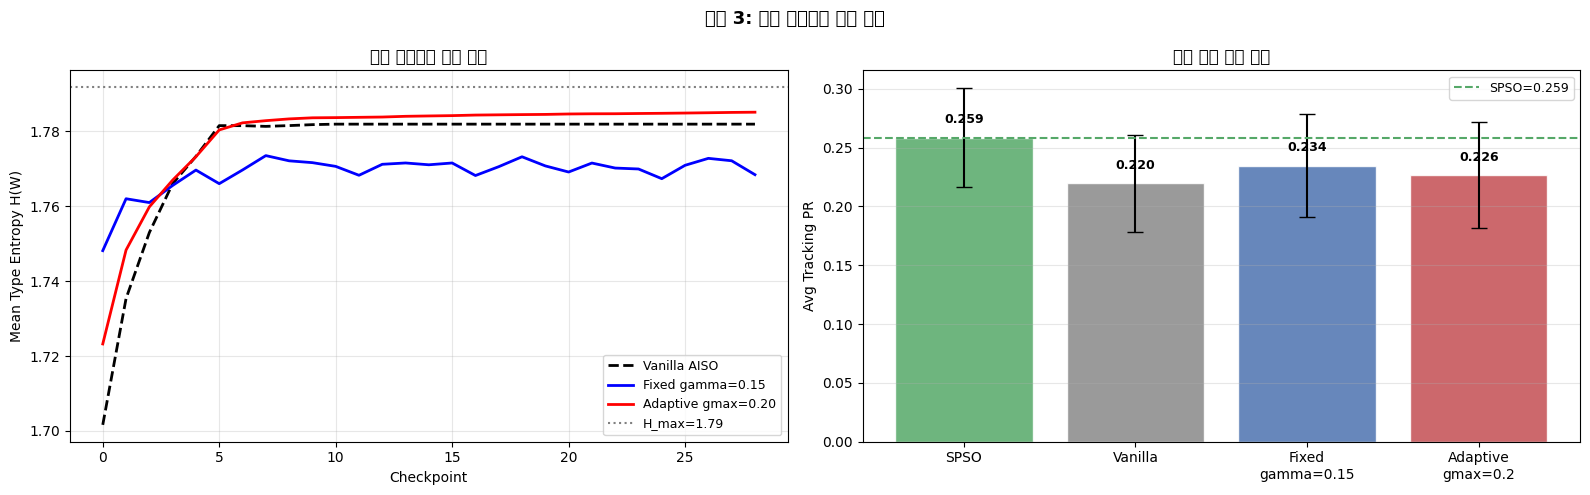

In [8]:
best_fixed_g  = max(gamma_results,    key=lambda g:  np.mean(gamma_results[g]))
best_adap_gm  = max(adaptive_results, key=lambda gm: np.mean(adaptive_results[gm]))

_, ent_vanilla = run_aiso_vanilla(seed=0)
_, ent_fixed   = run_aiso_entropy(seed=0, gamma=best_fixed_g, adaptive=False)
_, ent_adap    = run_aiso_entropy(seed=0, adaptive=True, gamma_max=best_adap_gm)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
steps = range(len(ent_vanilla))
ax.plot(steps, ent_vanilla, 'k--', lw=2, label='Vanilla AISO')
ax.plot(steps, ent_fixed,   'b-',  lw=2, label=f'Fixed gamma={best_fixed_g:.2f}')
ax.plot(steps, ent_adap,    'r-',  lw=2, label=f'Adaptive gmax={best_adap_gm:.2f}')
ax.axhline(np.log(N_TYPES), color='gray', ls=':', lw=1.5, label=f'H_max={np.log(N_TYPES):.2f}')
ax.set_xlabel('Checkpoint'); ax.set_ylabel('Mean Type Entropy H(W)')
ax.set_title('타입 엔트로피 시간 추이', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
names  = ['SPSO', 'Vanilla', f'Fixed\ngamma={best_fixed_g}', f'Adaptive\ngmax={best_adap_gm}']
means  = [spso_mean, vanilla_mean,
          np.mean(gamma_results[best_fixed_g]),
          np.mean(adaptive_results[best_adap_gm])]
stds   = [np.std(spso_scores), np.std(vanilla_scores),
          np.std(gamma_results[best_fixed_g]),
          np.std(adaptive_results[best_adap_gm])]
colors = ['#55A868', '#888888', '#4C72B0', '#C44E52']
bars = ax.bar(range(4), means, yerr=stds, capsize=6,
              color=colors, alpha=0.85, edgecolor='white')
ax.axhline(spso_mean, color='#55A868', ls='--', lw=1.5, label=f'SPSO={spso_mean:.3f}')
ax.set_xticks(range(4)); ax.set_xticklabels(names)
ax.set_ylabel('Avg Tracking PR'); ax.set_title('동적 환경 추적 성능', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.01, f'{m:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle('실험 3: 타입 엔트로피 주입 결과', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('exp3_entropy_injection.png', bbox_inches='tight', dpi=120)
plt.show()

## 부작용 체크: 정적 다봉 환경에서 수렴 방해 없는가?

엔트로피 주입이 동적 환경에 도움이 되더라도 **정적 다봉 환경(PR=0.977)에서 수렴을 방해**할 수 있음.

In [9]:
def make_static_gm9(seed=42):
    rng = np.random.RandomState(seed)
    centers = rng.rand(9, 2) * 0.8 + 0.1
    def f(x):
        return float(sum(np.exp(-np.sum((np.array(x)[:2]-c)**2)/0.02) for c in centers))
    return f, centers

def run_static(seed=0, gamma=0.0, adaptive=False, gamma_max=0.10):
    f_s, centers = make_static_gm9()
    rng = np.random.RandomState(seed)
    X = rng.rand(N_AG, 2)
    M = rng.uniform(M_LOW, W_REPEL, (N_TYPES, N_TYPES))
    W = rng.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f_s(X[i]) for i in range(N_AG)])
    H_max = np.log(N_TYPES)
    for it in range(200):
        gamma_t = gamma_max*(1.0 - type_entropy(W)/H_max) if adaptive else gamma
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            j = rng.randint(N_AG)
            while j == i: j = rng.randint(N_AG)
            nX = np.clip(X[i] + ALPHA*C[i,j]*(X[j]-X[i]), 0, 1)
            ns = f_s(nX)
            if ns > S[i]:
                X[i] = nX; S[i] = ns
                W_new = (1-BETA)*W[i] + BETA*W[j]; W_new /= W_new.sum()
                if gamma_t > 0:
                    noise = rng.dirichlet(np.ones(N_TYPES))
                    W_new = (1-gamma_t)*W_new + gamma_t*noise; W_new /= W_new.sum()
                W[i] = W_new
    tol = 0.15
    return sum(1 for c in centers if np.min(np.linalg.norm(X - c, axis=1)) < tol) / 9

print("정적 9-peak 부작용 체크...")
sv = [run_static(seed=s, gamma=0.0)            for s in range(20)]
sf = [run_static(seed=s, gamma=best_fixed_g)   for s in range(20)]
sa = [run_static(seed=s, adaptive=True, gamma_max=best_adap_gm) for s in range(20)]

print(f"\n정적 9-peak Peak Recall (20 runs):")
print(f"  Vanilla AISO       : {np.mean(sv):.3f} +/- {np.std(sv):.3f}")
print(f"  Fixed gamma={best_fixed_g:.2f}       : {np.mean(sf):.3f} +/- {np.std(sf):.3f}  (변화: {np.mean(sf)-np.mean(sv):+.3f})")
print(f"  Adaptive gmax={best_adap_gm:.2f}    : {np.mean(sa):.3f} +/- {np.std(sa):.3f}  (변화: {np.mean(sa)-np.mean(sv):+.3f})")

정적 9-peak 부작용 체크...

정적 9-peak Peak Recall (20 runs):
  Vanilla AISO       : 0.961 +/- 0.064
  Fixed gamma=0.15       : 0.950 +/- 0.074  (변화: -0.011)
  Adaptive gmax=0.20    : 0.950 +/- 0.074  (변화: -0.011)


In [10]:
print("=" * 60)
print("실험 3: 타입 엔트로피 주입 - 최종 결과")
print("=" * 60)
bfp = np.mean(gamma_results[best_fixed_g])
bap = np.mean(adaptive_results[best_adap_gm])
print(f"\n[동적 환경, {N_RUNS} runs]")
print(f"  SPSO (기준선)          : {spso_mean:.4f} +/- {np.std(spso_scores):.4f}")
print(f"  Vanilla AISO           : {vanilla_mean:.4f} +/- {np.std(vanilla_scores):.4f}")
print(f"  Fixed gamma={best_fixed_g:.2f}          : {bfp:.4f} +/- {np.std(gamma_results[best_fixed_g]):.4f}",
      "★ SPSO 초과" if bfp > spso_mean else f"({bfp-spso_mean:+.4f} vs SPSO)")
print(f"  Adaptive gmax={best_adap_gm:.2f}      : {bap:.4f} +/- {np.std(adaptive_results[best_adap_gm]):.4f}",
      "★ SPSO 초과" if bap > spso_mean else f"({bap-spso_mean:+.4f} vs SPSO)")
print(f"\n[정적 9-peak 부작용, 20 runs]")
print(f"  Vanilla                : {np.mean(sv):.3f}")
print(f"  Fixed gamma={best_fixed_g:.2f}          : {np.mean(sf):.3f}  ({np.mean(sf)-np.mean(sv):+.3f})")
print(f"  Adaptive gmax={best_adap_gm:.2f}      : {np.mean(sa):.3f}  ({np.mean(sa)-np.mean(sv):+.3f})")
print("=" * 60)

실험 3: 타입 엔트로피 주입 - 최종 결과

[동적 환경, 10 runs]
  SPSO (기준선)          : 0.2586 +/- 0.0421
  Vanilla AISO           : 0.2195 +/- 0.0416
  Fixed gamma=0.15          : 0.2345 +/- 0.0438 (-0.0241 vs SPSO)
  Adaptive gmax=0.20      : 0.2264 +/- 0.0450 (-0.0322 vs SPSO)

[정적 9-peak 부작용, 20 runs]
  Vanilla                : 0.961
  Fixed gamma=0.15          : 0.950  (-0.011)
  Adaptive gmax=0.20      : 0.950  (-0.011)


---
## Part 2: GNN 서브그래프 샘플링에서도 효과 있는가?

동적 벤치마크에서 타입 엔트로피 주입이 효과 있다면,
**실제 Elliptic Bitcoin GNN 서브그래프 샘플링**에서도 도움이 되는지 확인해야 함.

GNN 서브그래프 샘플링은 정적 문제지만 **다봉 구조**가 있음:
- 고차수 허브 노드 집단
- 시간적 illicit 밀집 집단
- illicit 이웃 링 집단

타입 다양성 유지 → 각 집단을 독립적으로 커버하는 에이전트 유지 → 샘플 다양성 향상

**가설**: 작은 gamma(0.01~0.05)는 도움, 큰 gamma는 수렴 방해

In [13]:
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings; warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'

print('Elliptic 데이터 로딩...')
feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')

labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1, 167)]
X_all = labeled[feat_cols].values.astype(float)
y_all = labeled["y"].values
ts_all = labeled["timestep"].values
N_NODES = len(labeled)
txid_to_idx = {txid: i for i, txid in enumerate(labeled["txId"].values)}

# edge index — txId1/txId2 둘 다 유효한 행만 같이 필터링
e_s = edge_df['txId1'].map(txid_to_idx)
e_d = edge_df['txId2'].map(txid_to_idx)
valid = e_s.notna() & e_d.notna()
s_arr = e_s[valid].astype(int).values
d_arr = e_d[valid].astype(int).values
mask  = (s_arr < N_NODES) & (d_arr < N_NODES)
edge_index = torch.tensor(np.stack([s_arr[mask], d_arr[mask]]), dtype=torch.long)
ei_np2 = edge_index.numpy()

SPLIT_T = 34
train_mask = ts_all <= SPLIT_T
test_mask  = ts_all >  SPLIT_T
train_illicit_idx = np.where(train_mask & (y_all == 1))[0]
train_licit_idx   = np.where(train_mask & (y_all == 0))[0]
train_anom_idx    = train_illicit_idx
N_LICIT = 10000; N_SEEN = 1000

X_scaled = StandardScaler().fit_transform(X_all)
X_anom_pca = PCA(30).fit_transform(X_scaled)[train_anom_idx]

print(f"로딩 완료: {N_NODES:,} 노드, illicit train={len(train_anom_idx):,}")

Elliptic 데이터 로딩...
로딩 완료: 46,564 노드, illicit train=3,462


In [14]:
# 12차원 도메인 피처 (elliptic_gnn_showdown Section 11과 동일)
neigh_count    = np.bincount(ei_np2[0], minlength=N_NODES).astype(float)
node_degree    = neigh_count.copy()
illicit_labels = y_all.astype(float)
illicit_neigh_sum = np.zeros(N_NODES)
np.add.at(illicit_neigh_sum, ei_np2[0], illicit_labels[ei_np2[1]])
illicit_neigh_ratio = illicit_neigh_sum / np.maximum(neigh_count, 1)

# 2홉 illicit 접촉도
neigh2_illicit = np.zeros(N_NODES)
np.add.at(neigh2_illicit, ei_np2[0], illicit_neigh_ratio[ei_np2[1]])
neigh2_illicit /= np.maximum(neigh_count, 1)

# 타임스텝별 illicit 밀도
ts_illicit_rate_map = {}
for t in np.unique(ts_all):
    mask_t = ts_all == t
    ts_illicit_rate_map[t] = y_all[mask_t].mean()
node_ts_illicit_rate = np.array([ts_illicit_rate_map[t] for t in ts_all])

local_feat = X_scaled[:, 1:94]
agg_feat   = X_scaled[:, 94:166]
local_mean = local_feat.mean(1); local_std = local_feat.std(1); local_max = local_feat.max(1)
agg_mean   = agg_feat.mean(1);   agg_std   = agg_feat.std(1);   agg_max   = agg_feat.max(1)
ts_min = ts_all.min(); ts_max = ts_all.max()
ts_norm = (ts_all - ts_min) / max(ts_max - ts_min, 1)
hub_fraud = node_degree * illicit_neigh_ratio

domain_feat_raw = np.stack([node_degree, illicit_neigh_ratio, neigh2_illicit,
    node_ts_illicit_rate, local_mean, local_std, local_max,
    agg_mean, agg_std, agg_max, ts_norm, hub_fraud], axis=1)
domain_feat_norm = MMS().fit_transform(domain_feat_raw)
X_anom_domain = domain_feat_norm[train_anom_idx]
N_DOM = X_anom_domain.shape[1]  # 12

print(f'도메인 피처: {N_DOM}차원 x {len(train_anom_idx):,} 이상 노드')

도메인 피처: 12차원 x 3,462 이상 노드


In [15]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.lin(x)

_LOOKUP = np.full(N_NODES, -1, dtype=np.int32)

def evaluate_gnn(sampled_anom_idx, seed=42):
    rng_t = torch.manual_seed(seed)
    licit_idx = np.random.RandomState(seed).choice(train_licit_idx, N_LICIT, replace=False)
    train_idx = np.concatenate([licit_idx, train_anom_idx[sampled_anom_idx]])
    _LOOKUP[:] = -1
    for loc, glob in enumerate(train_idx): _LOOKUP[glob] = loc
    sub_src = []; sub_dst = []
    for s, d in zip(ei_np2[0], ei_np2[1]):
        if _LOOKUP[s] >= 0 and _LOOKUP[d] >= 0:
            sub_src.append(_LOOKUP[s]); sub_dst.append(_LOOKUP[d])
    if not sub_src:
        return {'PR-AUC': 0.0, 'F1': 0.0, 'AUC': 0.0}
    ei_sub = torch.tensor([sub_src, sub_dst], dtype=torch.long).to(DEVICE)
    X_tr = torch.tensor(X_scaled[train_idx], dtype=torch.float).to(DEVICE)
    y_tr = torch.tensor(y_all[train_idx],    dtype=torch.long).to(DEVICE)
    model = GCN(X_tr.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    w     = torch.tensor([1.0, 10.0]).to(DEVICE)
    for _ in range(100):
        model.train(); opt.zero_grad()
        F.cross_entropy(model(X_tr, ei_sub), y_tr, weight=w).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        test_idx = np.where(test_mask)[0]
        X_te = torch.tensor(X_scaled[test_idx], dtype=torch.float).to(DEVICE)
        src_te = []; dst_te = []
        te_set = set(test_idx.tolist())
        tidx_map = {g: l for l, g in enumerate(test_idx)}
        for s, d in zip(ei_np2[0], ei_np2[1]):
            if s in tidx_map and d in tidx_map:
                src_te.append(tidx_map[s]); dst_te.append(tidx_map[d])
        if not src_te:
            return {'PR-AUC': 0.0, 'F1': 0.0, 'AUC': 0.0}
        ei_te = torch.tensor([src_te, dst_te], dtype=torch.long).to(DEVICE)
        logits = model(X_te, ei_te)
        probs  = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        preds_b = (probs > 0.5).astype(int)
        y_te = y_all[test_idx]
    return {
        'PR-AUC': average_precision_score(y_te, probs),
        'F1':     f1_score(y_te, preds_b, zero_division=0),
        'AUC':    roc_auc_score(y_te, probs),
    }

print('GCN 평가 함수 정의 완료')

GCN 평가 함수 정의 완료


In [16]:
GNN_N_AG  = 20; GNN_N_IT = 80; GNN_ALPHA = 0.2; GNN_BETA = 0.08
GNN_M_LOW = -0.5; GNN_W_REPEL = 2.0

def _norm_gnn(X):
    mn, mx = X.min(0), X.max(0)
    return (X - mn) / np.where(mx - mn > 1e-8, mx - mn, 1.0)

def run_aiso_entropy_gnn(X_a, n, seed, n_types=12, gamma=0.0, adaptive=False, gamma_max=0.10):
    rng2 = np.random.RandomState(seed)
    Xn = _norm_gnn(X_a); N_a, D = Xn.shape
    X = Xn[rng2.choice(N_a, GNN_N_AG, replace=True)].copy().astype(float)
    W = rng2.dirichlet(np.ones(n_types), GNN_N_AG)
    M = rng2.uniform(GNN_M_LOW, GNN_W_REPEL, (n_types, n_types))
    visit = np.zeros(N_a)
    H_max = np.log(n_types)
    w_r = GNN_W_REPEL

    for t in range(GNN_N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X[i]-X[j])
                           for i in range(GNN_N_AG) for j in range(i+1, GNN_N_AG)])
            w_r = 1.0 + 3.0 * np.exp(-div / 0.12)

        # 적응형 gamma 계산
        if adaptive:
            H_now = -np.sum(np.clip(W,1e-10,1)*np.log(np.clip(W,1e-10,1)),axis=1).mean()
            gamma_t = gamma_max * (1.0 - H_now / H_max)
        else:
            gamma_t = gamma

        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(GNN_N_AG):
            ci = C[i].copy(); ci[i] = 0
            ta  = np.argsort(ci)[-3:]; tr2 = np.argsort(ci)[:3]
            Fv  = sum(ci[j]*(X[j]-X[i]) for j in ta)
            Fv += w_r * sum(ci[j]*(X[j]-X[i]) for j in tr2)
            Fv /= 6.0
            nn_idx = np.argmin(np.linalg.norm(Xn - np.clip(X[i]+GNN_ALPHA*Fv,0,1), axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            bja = ta[np.argmax(ci[ta])]
            # 타입 업데이트 + 돌연변이
            W_new = (1-GNN_BETA)*W[i] + GNN_BETA*W[bja]; W_new /= W_new.sum()
            if gamma_t > 0:
                noise = rng2.dirichlet(np.ones(n_types))
                W_new = (1-gamma_t)*W_new + gamma_t*noise; W_new /= W_new.sum()
            W[i] = W_new

    probs = visit + 1.0; probs /= probs.sum()
    return rng2.choice(N_a, n, replace=True, p=probs)

print('엔트로피 주입 GNN 샘플러 정의 완료')

엔트로피 주입 GNN 샘플러 정의 완료


In [18]:
SEEDS_VAL    = [0, 7, 42, 77, 123]
N_TYPES_DOM  = 12
KNOWN_BASELINE = 0.6041  # AISO(Dom, N=12) 기존 mean
KNOWN_STD      = 0.0250

# GNN 전용 gamma 그리드 탐색 (동적 결과와 무관하게 독립 탐색)
GNN_GAMMAS = [0.0, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15]
GNN_ADAP_MAXS = [0.05, 0.10, 0.15, 0.20]

gnn_results = {}

print("GNN gamma 그리드 탐색 (고정 gamma)...")
for g in GNN_GAMMAS:
    label = f"Fixed gamma={g:.2f}"
    print(f"  {label}", end=" ", flush=True)
    scores = []
    for sd in SEEDS_VAL:
        idx = run_aiso_entropy_gnn(X_anom_domain, N_SEEN, sd,
                                   n_types=N_TYPES_DOM, gamma=g, adaptive=False)
        scores.append(evaluate_gnn(idx)["PR-AUC"])
    gnn_results[label] = scores
    m, s = np.mean(scores), np.std(scores)
    flag = "★" if m > KNOWN_BASELINE else ""
    print(f"-> {m:.4f} +/- {s:.4f}  ({m-KNOWN_BASELINE:+.4f}) {flag}")

print("GNN gamma 그리드 탐색 (적응형 gamma)...")
for gm in GNN_ADAP_MAXS:
    label = f"Adaptive gmax={gm:.2f}"
    print(f"  {label}", end=" ", flush=True)
    scores = []
    for sd in SEEDS_VAL:
        idx = run_aiso_entropy_gnn(X_anom_domain, N_SEEN, sd,
                                   n_types=N_TYPES_DOM, adaptive=True, gamma_max=gm)
        scores.append(evaluate_gnn(idx)["PR-AUC"])
    gnn_results[label] = scores
    m, s = np.mean(scores), np.std(scores)
    flag = "★" if m > KNOWN_BASELINE else ""
    print(f"-> {m:.4f} +/- {s:.4f}  ({m-KNOWN_BASELINE:+.4f}) {flag}")

# 최적 gamma 찾기
best_gnn_label = max(gnn_results, key=lambda k: np.mean(gnn_results[k]))
best_gnn_mean  = np.mean(gnn_results[best_gnn_label])
print(f"최적 GNN gamma: {best_gnn_label}  mean={best_gnn_mean:.4f}")

GNN gamma 그리드 탐색 (고정 gamma)...
  Fixed gamma=0.00 -> 0.5810 +/- 0.0139  (-0.0231) 
  Fixed gamma=0.01 -> 0.5848 +/- 0.0180  (-0.0193) 
  Fixed gamma=0.02 -> 0.5816 +/- 0.0110  (-0.0225) 
  Fixed gamma=0.05 -> 0.5770 +/- 0.0155  (-0.0271) 
  Fixed gamma=0.08 -> 0.5823 +/- 0.0136  (-0.0218) 
  Fixed gamma=0.10 -> 0.5730 +/- 0.0237  (-0.0311) 
  Fixed gamma=0.15 -> 0.5934 +/- 0.0126  (-0.0107) 
GNN gamma 그리드 탐색 (적응형 gamma)...
  Adaptive gmax=0.05 -> 0.5862 +/- 0.0155  (-0.0179) 
  Adaptive gmax=0.10 -> 0.5818 +/- 0.0175  (-0.0223) 
  Adaptive gmax=0.15 -> 0.5800 +/- 0.0225  (-0.0241) 
  Adaptive gmax=0.20 -> 0.5807 +/- 0.0204  (-0.0234) 
최적 GNN gamma: Fixed gamma=0.15  mean=0.5934


Part 2: GNN 엔트로피 주입 gamma 탐색 결과
방법                              mean     std  vs 기존
-----------------------------------------------------------------
  기존 AISO(Dom, N=12)         0.6041  0.0250  (기준)
  Fixed gamma=0.15              0.5934  0.0126  -0.0107 
  Adaptive gmax=0.05            0.5862  0.0155  -0.0179 
  Fixed gamma=0.01              0.5848  0.0180  -0.0193 
  Fixed gamma=0.08              0.5823  0.0136  -0.0218 
  Adaptive gmax=0.10            0.5818  0.0175  -0.0223 
  Fixed gamma=0.02              0.5816  0.0110  -0.0225 
  Fixed gamma=0.00              0.5810  0.0139  -0.0231 
  Adaptive gmax=0.20            0.5807  0.0204  -0.0234 
  Adaptive gmax=0.15            0.5800  0.0225  -0.0241 
  Fixed gamma=0.05              0.5770  0.0155  -0.0271 
  Fixed gamma=0.10              0.5730  0.0237  -0.0311 


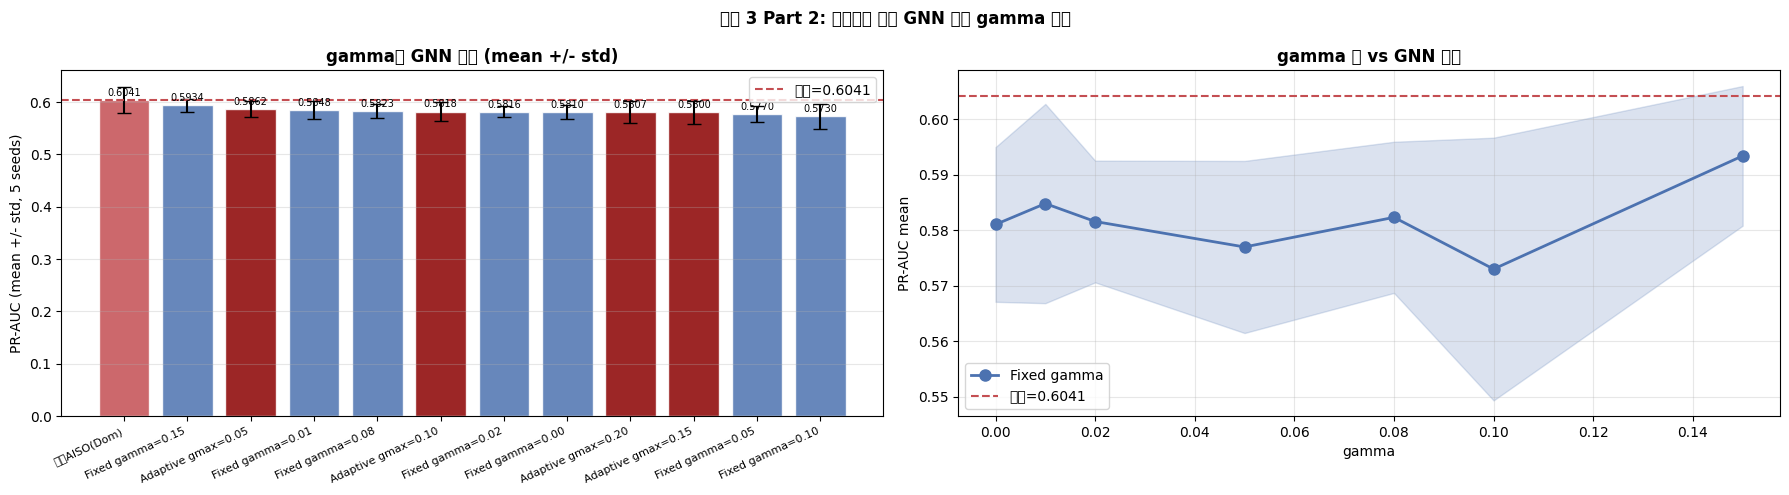

In [19]:
print("" + "=" * 65)
print("Part 2: GNN 엔트로피 주입 gamma 탐색 결과")
print("=" * 65)
print(f"{"방법":<28} {"mean":>7} {"std":>7}  vs 기존")
print("-" * 65)
print(f"  기존 AISO(Dom, N=12)        {KNOWN_BASELINE:>7.4f} {KNOWN_STD:>7.4f}  (기준)")
sorted_results = sorted(gnn_results.items(), key=lambda x: np.mean(x[1]), reverse=True)
for label, scores in sorted_results:
    m, s = np.mean(scores), np.std(scores)
    diff = m - KNOWN_BASELINE
    flag = "★" if m > KNOWN_BASELINE else ""
    print(f"  {label:<28} {m:>7.4f} {s:>7.4f}  {diff:+.4f} {flag}")
print("=" * 65)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 왼쪽: mean+std 바 차트
ax = axes[0]
all_labels = ["기존AISO(Dom)"] + [k for k,_ in sorted_results]
all_means  = [KNOWN_BASELINE] + [np.mean(v) for _,v in sorted_results]
all_stds   = [KNOWN_STD]      + [np.std(v)  for _,v in sorted_results]
clr = ["#C44E52"] + ["#4C72B0" if "Fixed" in k else "#8B0000" for k,_ in sorted_results]
bars = ax.bar(range(len(all_labels)), all_means, yerr=all_stds,
              capsize=5, color=clr, alpha=0.85, edgecolor="white")
ax.axhline(KNOWN_BASELINE, color="#C44E52", ls="--", lw=1.5, label=f"기존={KNOWN_BASELINE:.4f}")
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("PR-AUC (mean +/- std, 5 seeds)")
ax.set_title("gamma별 GNN 성능 (mean +/- std)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bar, m in zip(bars, all_means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.004, f"{m:.4f}",
            ha="center", va="bottom", fontsize=7)

# 오른쪽: gamma vs mean 라인 (고정 gamma만)
ax = axes[1]
fixed_gs  = [float(k.split("=")[1]) for k,_ in sorted_results if "Fixed" in k]
fixed_ms  = [np.mean(v) for k,v in sorted_results if "Fixed" in k]
fixed_ss  = [np.std(v)  for k,v in sorted_results if "Fixed" in k]
fixed_gs, fixed_ms, fixed_ss = zip(*sorted(zip(fixed_gs, fixed_ms, fixed_ss)))
ax.plot(fixed_gs, fixed_ms, "o-", color="#4C72B0", lw=2, ms=8, label="Fixed gamma")
ax.fill_between(fixed_gs,
                [m-s for m,s in zip(fixed_ms, fixed_ss)],
                [m+s for m,s in zip(fixed_ms, fixed_ss)],
                alpha=0.2, color="#4C72B0")
ax.axhline(KNOWN_BASELINE, color="#C44E52", ls="--", lw=1.5, label=f"기존={KNOWN_BASELINE:.4f}")
ax.set_xlabel("gamma"); ax.set_ylabel("PR-AUC mean")
ax.set_title("gamma 값 vs GNN 성능", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("실험 3 Part 2: 엔트로피 주입 GNN 최적 gamma 탐색", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("exp3_gnn_entropy.png", bbox_inches="tight", dpi=120)
plt.show()

In [22]:
# ---- 확장 실험: 큰 gamma + 반전 동화 ----

# 1. 큰 gamma 그리드 (0.15 이후 상승 추세 확인)
GNN_GAMMAS_EXT = [0.15, 0.20, 0.30, 0.40, 0.50]

gnn_results_ext = {}

print("[확장] Fixed gamma 그리드 (0.15~0.50)...")
for g in GNN_GAMMAS_EXT:
    label = f"Fixed gamma={g:.2f}"
    scores = []
    for sd in SEEDS_VAL:
        idx = run_aiso_entropy_gnn(X_anom_domain, N_SEEN, sd,
                                   n_types=N_TYPES_DOM, gamma=g, adaptive=False)
        scores.append(evaluate_gnn(idx)["PR-AUC"])
    gnn_results_ext[label] = scores
    m, s = np.mean(scores), np.std(scores)
    flag = "★" if m > KNOWN_BASELINE else ""
    print(f"  gamma={g:.2f}: {m:.4f} +/- {s:.4f}  ({m-KNOWN_BASELINE:+.4f}) {flag}")


# 2. 반전 동화 (anti-assimilation)
def run_aiso_antiassim_gnn(X_a, n, seed, n_types=12):
    """타입 업데이트를 반전: W_i가 W_j에서 멀어짐 (clip+normalize)"""
    rng2 = np.random.RandomState(seed)
    Xn = _norm_gnn(X_a); N_a, D = Xn.shape
    X = Xn[rng2.choice(N_a, GNN_N_AG, replace=True)].copy().astype(float)
    W = rng2.dirichlet(np.ones(n_types), GNN_N_AG)
    M = rng2.uniform(GNN_M_LOW, GNN_W_REPEL, (n_types, n_types))
    visit = np.zeros(N_a)
    w_r = GNN_W_REPEL

    for t in range(GNN_N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X[i]-X[j])
                           for i in range(GNN_N_AG) for j in range(i+1, GNN_N_AG)])
            w_r = 1.0 + 3.0 * np.exp(-div / 0.12)

        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(GNN_N_AG):
            ci = C[i].copy(); ci[i] = 0
            ta  = np.argsort(ci)[-3:]; tr2 = np.argsort(ci)[:3]
            Fv  = sum(ci[j]*(X[j]-X[i]) for j in ta)
            Fv += w_r * sum(ci[j]*(X[j]-X[i]) for j in tr2)
            Fv /= 6.0
            nn_idx = np.argmin(np.linalg.norm(Xn - np.clip(X[i]+GNN_ALPHA*Fv,0,1), axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            bja = ta[np.argmax(ci[ta])]
            # 반전 동화: i가 j에서 멀어짐
            W_new = (1 + GNN_BETA) * W[i] - GNN_BETA * W[bja]
            W_new = np.clip(W_new, 0, None)
            s_w = W_new.sum()
            if s_w < 1e-10:
                W_new = np.ones(n_types) / n_types  # 전체 붕괴 방지
            else:
                W_new /= s_w
            W[i] = W_new

    probs = visit + 1.0; probs /= probs.sum()
    return rng2.choice(N_a, n, replace=True, p=probs)


print()
print("[반전 동화] Anti-assimilation...")
scores_anti = []
for sd in SEEDS_VAL:
    idx = run_aiso_antiassim_gnn(X_anom_domain, N_SEEN, sd, n_types=N_TYPES_DOM)
    scores_anti.append(evaluate_gnn(idx)["PR-AUC"])
m_anti, s_anti = np.mean(scores_anti), np.std(scores_anti)
flag = "★" if m_anti > KNOWN_BASELINE else ""
print(f"  Anti-assimilation: {m_anti:.4f} +/- {s_anti:.4f}  ({m_anti-KNOWN_BASELINE:+.4f}) {flag}")


[확장] Fixed gamma 그리드 (0.15~0.50)...


KeyboardInterrupt: 

In [ ]:
# ---- 확장 결과 시각화 ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# 기존 fixed gamma 결과 (b006에서)
old_gs = [float(k.split("=")[1]) for k in gnn_results if "Fixed" in k]
old_ms = [np.mean(gnn_results[k]) for k in gnn_results if "Fixed" in k]
old_ss = [np.std(gnn_results[k])  for k in gnn_results if "Fixed" in k]
old_gs, old_ms, old_ss = zip(*sorted(zip(old_gs, old_ms, old_ss)))

# 확장 fixed gamma 결과 (b008에서, 0.15 중복 포함)
ext_gs = [float(k.split("=")[1]) for k in gnn_results_ext if "Fixed" in k]
ext_ms = [np.mean(gnn_results_ext[k]) for k in gnn_results_ext if "Fixed" in k]
ext_ss = [np.std(gnn_results_ext[k])  for k in gnn_results_ext if "Fixed" in k]
ext_gs, ext_ms, ext_ss = zip(*sorted(zip(ext_gs, ext_ms, ext_ss)))

# 전체 gamma 범위 합치기 (0.00~0.50)
all_gs = list(old_gs[:-1]) + list(ext_gs)  # 0.15 중복 제거 (ext 우선)
all_ms = list(old_ms[:-1]) + list(ext_ms)
all_ss = list(old_ss[:-1]) + list(ext_ss)

ax.plot(all_gs, all_ms, "o-", color="#4C72B0", lw=2, ms=8, label="Fixed gamma")
ax.fill_between(all_gs,
                [m-s for m,s in zip(all_ms, all_ss)],
                [m+s for m,s in zip(all_ms, all_ss)],
                alpha=0.2, color="#4C72B0")
ax.axhline(KNOWN_BASELINE, color="#C44E52", ls="--", lw=1.5, label=f"기존={KNOWN_BASELINE:.4f}")
ax.axhline(m_anti, color="#2ca02c", ls="-.", lw=2,
           label=f"Anti-assimilation={m_anti:.4f}")

ax.set_xlabel("gamma"); ax.set_ylabel("PR-AUC mean (5 seeds)")
ax.set_title("gamma 전체 범위 + 반전 동화 비교", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("exp3_gnn_ext.png", bbox_inches="tight", dpi=120)
plt.show()
print()
print("최종 비교:")
print(f"  기존 AISO(Dom,N=12): {KNOWN_BASELINE:.4f}")
best_ext = max(gnn_results_ext, key=lambda k: np.mean(gnn_results_ext[k]))
print(f"  최고 큰 gamma ({best_ext}): {np.mean(gnn_results_ext[best_ext]):.4f}")
print(f"  Anti-assimilation:   {m_anti:.4f}")


In [23]:
# ---- 구조적 타입 초기화 실험 ----
# W를 one-hot 역할 배정, M을 반발/인력 구조화
# -> 에이전트가 처음부터 다른 특성 축을 담당하도록 강제

def run_aiso_structured_gnn(X_a, n, seed, n_types=12,
                             beta_slow=0.02, m_diag=-2.0, m_offdiag=0.3):
    rng2 = np.random.RandomState(seed)
    Xn = _norm_gnn(X_a); N_a, D = Xn.shape

    # one-hot W 초기화 (에이전트별 역할 배정)
    W = np.zeros((GNN_N_AG, n_types))
    for i in range(GNN_N_AG):
        W[i, i % n_types] = 1.0
    noise = rng2.dirichlet(np.ones(n_types), GNN_N_AG) * 0.05
    W = W + noise
    W /= W.sum(1, keepdims=True)

    # 구조적 M (같은 타입 반발, 다른 타입 인력)
    M = np.full((n_types, n_types), m_offdiag)
    np.fill_diagonal(M, m_diag)

    X = Xn[rng2.choice(N_a, GNN_N_AG, replace=True)].copy().astype(float)
    visit = np.zeros(N_a)
    w_r = GNN_W_REPEL

    for t in range(GNN_N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X[i]-X[j])
                           for i in range(GNN_N_AG) for j in range(i+1, GNN_N_AG)])
            w_r = 1.0 + 3.0 * np.exp(-div / 0.12)

        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(GNN_N_AG):
            ci = C[i].copy(); ci[i] = 0
            ta  = np.argsort(ci)[-3:]; tr2 = np.argsort(ci)[:3]
            Fv  = sum(ci[j]*(X[j]-X[i]) for j in ta)
            Fv += w_r * sum(ci[j]*(X[j]-X[i]) for j in tr2)
            Fv /= 6.0
            nn_idx = np.argmin(np.linalg.norm(Xn - np.clip(X[i]+GNN_ALPHA*Fv,0,1), axis=1))
            X[i] = Xn[nn_idx]; visit[nn_idx] += 1.0
            bja = ta[np.argmax(ci[ta])]
            W_new = (1-beta_slow)*W[i] + beta_slow*W[bja]
            W_new /= W_new.sum()
            W[i] = W_new

    probs = visit + 1.0; probs /= probs.sum()
    return rng2.choice(N_a, n, replace=True, p=probs)


configs = [
    {"beta_slow": 0.02, "m_diag": -2.0, "m_offdiag": 0.3,  "label": "onehot b=0.02 M(-2,+0.3)"},
    {"beta_slow": 0.05, "m_diag": -2.0, "m_offdiag": 0.3,  "label": "onehot b=0.05 M(-2,+0.3)"},
    {"beta_slow": 0.08, "m_diag": -2.0, "m_offdiag": 0.3,  "label": "onehot b=0.08 M(-2,+0.3)"},
    {"beta_slow": 0.02, "m_diag": -1.0, "m_offdiag": 0.5,  "label": "onehot b=0.02 M(-1,+0.5)"},
    {"beta_slow": 0.02, "m_diag": -3.0, "m_offdiag": 0.1,  "label": "onehot b=0.02 M(-3,+0.1)"},
]

struct_results = {}
print(f"{'설정':<32} {'mean':>7} {'std':>7}  vs 기존")
print("-" * 60)
for cfg in configs:
    lbl = cfg["label"]
    scores = []
    for sd in SEEDS_VAL:
        idx = run_aiso_structured_gnn(X_anom_domain, N_SEEN, sd,
                                      n_types=N_TYPES_DOM,
                                      beta_slow=cfg["beta_slow"],
                                      m_diag=cfg["m_diag"],
                                      m_offdiag=cfg["m_offdiag"])
        scores.append(evaluate_gnn(idx)["PR-AUC"])
    m, s = np.mean(scores), np.std(scores)
    struct_results[lbl] = scores
    flag = "★" if m > KNOWN_BASELINE else ""
    print(f"  {lbl:<30} {m:.4f} {s:.4f}  {m-KNOWN_BASELINE:+.4f} {flag}")

print()
print(f"  기존 AISO(Dom, N=12)           {KNOWN_BASELINE:.4f}  (기준)")
best_lbl = max(struct_results, key=lambda k: np.mean(struct_results[k]))
best_m   = np.mean(struct_results[best_lbl])
print(f"  최고: {best_lbl}  -> {best_m:.4f}")


설정                                  mean     std  vs 기존
------------------------------------------------------------
  onehot b=0.02 M(-2,+0.3)       0.5443 0.0545  -0.0598 
  onehot b=0.05 M(-2,+0.3)       0.5497 0.0398  -0.0544 
  onehot b=0.08 M(-2,+0.3)       0.5478 0.0427  -0.0563 
  onehot b=0.02 M(-1,+0.5)       0.5424 0.0560  -0.0617 
  onehot b=0.02 M(-3,+0.1)       0.5434 0.0487  -0.0607 

  기존 AISO(Dom, N=12)           0.6041  (기준)
  최고: onehot b=0.05 M(-2,+0.3)  -> 0.5497
